In [2]:
import numpy as np
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from aeon.transformations.collection.interval_based import QUANTTransformer
import numpy as np
import polars as pl
from aeon.classification.base import BaseClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
import os
from aeon.transformations.collection.convolution_based import Rocket
from aeon.datasets.tsc_datasets import univariate
from sklearn.base import clone
from aeon.classification.convolution_based import MultiRocketHydraClassifier
from aeon.classification.convolution_based import RocketClassifier
from sklearn.metrics import accuracy_score
from aeon.classification.interval_based import QUANTClassifier
from autotsc import utils, models
from tqdm import tqdm
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.interval_based import QUANTClassifier
from aeon.classification.shapelet_based import RDSTClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier


2025-12-09 08:47:17.232594: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def generate_folds(X, y, n_splits=5, n_repetitions=5, random_state=0):
    all_folds = []
    for i in range(n_repetitions):
        folds = utils.get_folds(X, y, n_splits=n_splits, random_state=random_state+i)
        all_folds.extend(folds)
    return all_folds

class CrossValidationWrapper(BaseClassifier):
    def __init__(self, model, k_folds=10, n_repetitions=1, random_state=None):
        super().__init__()
        self.model = model
        self.trained_models_ = []
        self.fit_time_ = []
        self.fit_time_mean_ = None
        self.predict_time_ = []
        self.predict_time_mean_ = None
        self.cv_splits = None
        self.k_folds = k_folds
        self.n_repetitions = n_repetitions
        self.random_state = random_state

    def _fit(self, X, y):
        raise NotImplementedError()

    def _predict_proba(self, X):
        predictions = []
        for model in self.trained_models_:
            proba = model.predict_proba(X)
            predictions.append(proba)
        avg_proba = np.mean(predictions, axis=0)
        return avg_proba

    def _predict(self, X):
        probas = self._predict_proba(X)
        predicted_indices = np.argmax(probas, axis=1)
        return self.classes_[predicted_indices]

    def get_all_oof_proba(self):
        return pl.DataFrame(self.oof_proba).sort('index', maintain_order=True)

    def _fit_predict_proba(self, X, y):
        if self.cv_splits is None:
            self.cv_splits = generate_folds(X, y, n_splits=self.k_folds, n_repetitions=self.n_repetitions, random_state=self.random_state)
        self.oof_proba = []
        for train_idx, val_idx in tqdm(self.cv_splits):
            model_clone = clone(self.model)
            X_train, y_train = X[train_idx], y[train_idx]
            X_valid, _ = X[val_idx], y[val_idx]
            model_clone.fit(X_train, y_train)
            self.trained_models_.append(model_clone)
            proba = model_clone.predict_proba(X_valid)
            prob_columns = []
            for idx, p in zip(val_idx, proba):
                d = {
                    'index': idx,
                }
                for scls, prob in zip(model_clone.classes_, p):
                    k = f'proba_class_{scls}'
                    d[k] = prob.item()
                    if k not in prob_columns:
                        prob_columns.append(k)
                self.oof_proba.append(d)
        return pl.DataFrame(self.oof_proba).group_by('index').mean().sort('index').select(prob_columns).to_numpy()

In [3]:
from sklearn.base import BaseEstimator as SKLearnBaseEstimator

class TabCrossValidationWrapper(SKLearnBaseEstimator):
    def __init__(self, model, k_folds=10, n_repetitions=3):
        super().__init__()
        self.model = model
        self.trained_models_ = []
        self.fit_time_ = []
        self.fit_time_mean_ = None
        self.predict_time_ = []
        self.predict_time_mean_ = None
        self.cv_splits = None
        self.k_folds = k_folds
        self.n_repetitions = n_repetitions 

    def _fit(self, X, y):
        raise NotImplementedError()

    def _predict_proba(self, X):
        predictions = []
        for model in self.trained_models_:
            proba = model.predict_proba(X)
            predictions.append(proba)
        avg_proba = np.mean(predictions, axis=0)
        return avg_proba

    def _predict(self, X):
        probas = self._predict_proba(X)
        predicted_indices = np.argmax(probas, axis=1)
        return self.classes_[predicted_indices]

    def get_all_oof_proba(self):
        return pl.DataFrame(self.oof_proba).sort('index', maintain_order=True)

    def fit_predict_proba(self, X, y):
        return self._fit_predict_proba(X, y)

    def _fit_predict_proba(self, X, y):
        self.classes_ = sorted(list(np.unique(y)))
        if self.cv_splits is None:
            self.cv_splits = generate_folds(X, y, n_splits=self.k_folds, n_repetitions=self.n_repetitions, random_state=0)
        self.oof_proba = []
        for train_idx, val_idx in tqdm(self.cv_splits):
            model_clone = clone(self.model)
            X_train, y_train = X[train_idx], y[train_idx]
            X_valid, _ = X[val_idx], y[val_idx]
            model_clone.fit(X_train, y_train)
            self.trained_models_.append(model_clone)
            proba = model_clone.predict_proba(X_valid)
            prob_columns = []
            for idx, p in zip(val_idx, proba):
                d = {
                    'index': idx,
                }
                for scls, prob in zip(model_clone.classes_, p):
                    k = f'proba_class_{scls}'
                    d[k] = prob.item()
                    if k not in prob_columns:
                        prob_columns.append(k)
                self.oof_proba.append(d)
        return pl.DataFrame(self.oof_proba).group_by('index').mean().sort('index').select(prob_columns).to_numpy()

In [4]:
from aeon.pipeline import make_pipeline as aeon_make_pipeline
from autotsc import utils, models, transformers


In [5]:
class Stacker(BaseClassifier):
    def __init__(self, random_state=None, n_repetitions = 1):
        super().__init__()
        self.n_repetitions = n_repetitions
        k_folds=10
        self.random_state = random_state
        self.m1 = CrossValidationWrapper(MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state), k_folds=k_folds, n_repetitions=n_repetitions, random_state=random_state)
        self.m2 = CrossValidationWrapper(QUANTClassifier(random_state=random_state), k_folds=k_folds, n_repetitions=n_repetitions, random_state=random_state)
        self.m3 = CrossValidationWrapper(RDSTClassifier(n_jobs=-1, random_state=random_state), k_folds=k_folds, n_repetitions=n_repetitions, random_state=random_state)
        self.m4 = CrossValidationWrapper(
            aeon_make_pipeline(
                transformers.RankTransform(),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            ), k_folds=k_folds, n_repetitions=n_repetitions, random_state=random_state
        )
        self.m5 = CrossValidationWrapper(
            aeon_make_pipeline(
                transformers.LocalMeanSubtract(),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            ), k_folds=k_folds, n_repetitions=n_repetitions, random_state=random_state
        )
        self.use_caruana = False # !!!!!!!!!!!!!!!!!!!!!!
        #model = CatBoostClassifier(
        #    iterations=10000,
        #    early_stopping_rounds=50,
        #    learning_rate=0.0005,
        #    verbose=0
        #)
#
        #self.mm1 = TabCrossValidationWrapper(model=model, k_folds=k_folds, n_repetitions=n_repetitions)

    def _fit(self, X, y):
        def add_argmax_label(df: pl.DataFrame, label_col="label"):
            numeric_cols = [c for c in df.columns if df[c].dtype.is_numeric()]

            return df.with_columns(
                pl.struct(numeric_cols)
                .map_elements(lambda row: max(row, key=row.get))
                .alias(label_col)
            )
        self.train_pred5 = self.m5.fit_predict_proba(X, y)
        preds = pl.DataFrame(self.train_pred5, schema=list(self.classes_)).pipe(add_argmax_label)['label'].to_list()
        acc = accuracy_score(y, preds)
        print('LMS MR vall acc', acc)

        self.train_pred4 = self.m4.fit_predict_proba(X, y)
        preds = pl.DataFrame(self.train_pred4, schema=list(self.classes_)).pipe(add_argmax_label)['label'].to_list()
        acc = accuracy_score(y, preds)
        print('RANKED MR vall acc', acc)

        self.train_pred1 = self.m1.fit_predict_proba(X, y)
        preds = pl.DataFrame(self.train_pred1, schema=list(self.classes_)).pipe(add_argmax_label)['label'].to_list()
        acc = accuracy_score(y, preds)
        print('MR vall acc', acc)

        self.train_pred2 = self.m2.fit_predict_proba(X, y)
        preds = pl.DataFrame(self.train_pred2, schema=list(self.classes_)).pipe(add_argmax_label)['label'].to_list()
        acc = accuracy_score(y, preds)
        print('QUANT vall acc', acc)

        self.train_pred3 = self.m3.fit_predict_proba(X, y)
        preds = pl.DataFrame(self.train_pred3, schema=list(self.classes_)).pipe(add_argmax_label)['label'].to_list()
        acc = accuracy_score(y, preds)
        print('RDST vall acc', acc)


        #self.train_predmm1 = self.mm1.fit_predict_proba(np.hstack([self.train_pred1, self.train_pred2, self.train_pred3]), y)
        #preds = pl.DataFrame(self.train_predmm1, schema=list(self.classes_)).pipe(add_argmax_label)['label'].to_list()
        #acc = accuracy_score(y, preds)
        #print('Meta CatBoost vall acc', acc)


        if self.use_caruana:
            # reshuffle self.train_pred1 to check if Caruana works correctly
            X = np.random.rand(self.train_pred1.shape[0], self.train_pred1.shape[1])
            X = X / X.sum(axis=1, keepdims=True)
            model_predictions = {
                'MR': self.train_pred1,
                'QUANT': self.train_pred2,
                'RDST': self.train_pred3,
                'TEST': X,
            }
            def accuracy(y_true, y_pred):
                # Convert to integers (0,1,2,3) for argmax comparison
                # but *does not* affect predictions
                unique = sorted(set(y_true))
                mapping = {label: i for i, label in enumerate(unique)}
                y_idx = np.array([mapping[x] for x in y_true])

                y_hat = np.argmax(y_pred, axis=1)
                return np.mean(y_hat == y_idx)

            from amltk.ensembling.weighted_ensemble_caruana import weighted_ensemble_caruana
            self.weights, traj, final_pred = weighted_ensemble_caruana(
                model_predictions=model_predictions,
                targets=y,
                size=50,                                  # ensemble size / num of draws
                metric=accuracy,
                select=max,
            )
            print(self.weights)
            
        else:
            X_meta = np.hstack([self.train_pred1, self.train_pred2, self.train_pred3, self.train_pred4, self.train_pred5])
            self.meta_model = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", RidgeClassifierCV(alphas=np.logspace(-4, 4, 10)))
            ])
            self.meta_model.fit(X_meta, y)

    def _predict(self, X):
        self.test_pred1 = self.m1._predict_proba(X)
        self.test_pred2 = self.m2._predict_proba(X)
        self.test_pred3 = self.m3._predict_proba(X)
        self.test_pred4 = self.m4._predict_proba(X)
        self.test_pred5 = self.m5._predict_proba(X)

        # self.test_predmm1 = self.mm1._predict_proba(np.hstack([self.test_pred1, self.test_pred2, self.test_pred3]))

        if self.use_caruana:
            X = np.random.rand(self.test_pred1.shape[0], self.test_pred1.shape[1])
            X = X / X.sum(axis=1, keepdims=True)

            model_predictions = {
                'MR': self.test_pred1,
                'QUANT': self.test_pred2,
                'RDST': self.test_pred3,
                'TEST': X,
            }

            final_probs = np.zeros((len(X), len(self.classes_)), dtype=float)
            for model_id, weight in self.weights.items():
                final_probs += weight * model_predictions[model_id]
            predicted_indices = np.argmax(final_probs, axis=1)
            return self.classes_[predicted_indices]
        else:
            X_meta = np.hstack([self.test_pred1, self.test_pred2, self.test_pred3, self.test_pred4, self.test_pred5])
            return self.meta_model.predict(X_meta)


In [6]:
import numpy as np
from scipy.interpolate import interp1d
from aeon.transformations.collection.base import BaseCollectionTransformer


class DownsampleTransformer(BaseCollectionTransformer):
    _tags = {
        "X_inner_type": ["np-list", "numpy3D"],
        "capability:multivariate": True,
        "capability:unequal_length": True,
        "fit_is_empty": True,
    }

    def __init__(self, proportion):
        self.proportion = proportion
        super().__init__()

    def _transform(self, X, y=None):
        self._check_parameters()

        is_np = isinstance(X, np.ndarray)
        out = []

        for x in X:
            c, t = x.shape
            new_t = max(2, int(round(t * self.proportion)))

            old_grid = np.linspace(0, 1, t)
            new_grid = np.linspace(0, 1, new_t)

            xr = np.zeros((c, new_t))
            for i in range(c):
                f = interp1d(old_grid, x[i], kind="linear")
                xr[i] = f(new_grid)

            out.append(xr)

        return np.asarray(out) if is_np else out

    def _check_parameters(self):
        if not (0 < self.proportion < 1):
            raise ValueError("proportion must be between 0 and 1")


In [7]:
dataset = 'Worms'
dataset = 'Car'

X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
random_state=1127

# RESAMPLING BAING USED HERE !!!!!!!!!!!!!!!!!!!!
#from aeon.benchmarking import resampling
#X_train, y_train, X_test, y_test = resampling.stratified_resample_data(X_train, y_train, X_test, y_test,random_state=random_state)


(60, 1, 577) (60,) (60, 1, 577) (60,)


In [8]:
m = MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
m.fit(X_train, y_train)
pred = m.predict(X_test)
acc = accuracy_score(y_test, pred)
acc

0.9166666666666666

In [9]:
t = transformers.RankTransform()
X_train_ds = t.fit_transform(X_train)
X_test_ds = t.transform(X_test)
m = MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
m.fit(X_train_ds, y_train)
pred = m.predict(X_test_ds)
acc = accuracy_score(y_test, pred)
acc

0.9333333333333333

In [10]:
from autotsc.transformers import CumSum
t = CumSum()
X_train_cs = t.fit_transform(X_train)
X_test_cs = t.transform(X_test)
m = QUANTClassifier(random_state=random_state)
m.fit(X_train_cs, y_train)
pred = m.predict(X_test_cs)
acc = accuracy_score(y_test, pred)
acc

0.8

In [11]:
m = QUANTClassifier(random_state=random_state)
m.fit(X_train, y_train)
pred = m.predict(X_test)
acc = accuracy_score(y_test, pred)
acc

0.9166666666666666

In [12]:
m = RDSTClassifier(n_jobs=-1, random_state=random_state)
m.fit(X_train, y_train)
pred = m.predict(X_test)
acc = accuracy_score(y_test, pred)
acc

0.9333333333333333

In [13]:
m = Stacker(random_state=random_state, n_repetitions=1)
m.fit(X_train, y_train)
preds = m.predict(X_test)
acc = accuracy_score(y_test, preds)
acc

100%|██████████| 10/10 [00:36<00:00,  3.65s/it]


LMS MR vall acc 0.95


100%|██████████| 10/10 [00:37<00:00,  3.78s/it]


RANKED MR vall acc 0.8666666666666667


100%|██████████| 10/10 [00:38<00:00,  3.89s/it]


...

100%|██████████| 10/10 [00:07<00:00,  1.27it/s]


QUANT vall acc 0.9


100%|██████████| 10/10 [00:13<00:00,  1.34s/it]


RDST vall acc 0.9333333333333333


0.9333333333333333

In [14]:
y_train.shape

(60,)

In [15]:
dfgdfg=dsfsdf

NameError: name 'dsfsdf' is not defined

In [ ]:
!uv pip install amltk

In [ ]:
y_train.shape

In [ ]:
#from amltk.ensembling.weighted_ensemble_caruana import weighted_ensemble_caruana
#
#X1 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X1 = X1 / X1.sum(axis=1, keepdims=True)
#
#X2 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X2 = X2 / X2.sum(axis=1, keepdims=True)
#
#X3 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X3 = X3 / X3.sum(axis=1, keepdims=True)
#
#model_predictions = {
#    'MR': m.test_pred1,
#    'QUANT': m.test_pred2,
#    'RDST': m.test_pred3,
#    'TEST': X1,
#    'TEST2': X2,
#    'TEST3': X3,
#}
#
#for k, v in model_predictions.items():
#    print(k, v.shape)
#
#def accuracy(y_true, y_pred):
#    # Convert to integers (0,1,2,3) for argmax comparison
#    # but *does not* affect predictions
#    unique = sorted(set(y_true))
#    mapping = {label: i for i, label in enumerate(unique)}
#    y_idx = np.array([mapping[x] for x in y_true])
#
#    y_hat = np.argmax(y_pred, axis=1)
#    return np.mean(y_hat == y_idx)
#
#weights, traj, final_pred = weighted_ensemble_caruana(
#    model_predictions=model_predictions,
#    targets=y_test,
#    size=350,                                  # ensemble size / num of draws
#    metric=accuracy,
#    select=max,
#)
#
#weights

In [ ]:
traj

In [ ]:
class 

In [ ]:
weights

In [ ]:
traj

In [ ]:
final_pred

In [ ]:
xvxcvxc=Vxcvxv

In [12]:
write_dir = "experiments/stacking_run_v1"
os.makedirs(write_dir, exist_ok=True)

In [13]:
def get_model(model_name, random_state):
    if model_name == 'mr-hydra':
        return MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
    elif model_name == 'quant':
        return QUANTClassifier(random_state=random_state)
    elif model_name == 'rdst':
        return RDSTClassifier(n_jobs=-1, random_state=random_state)
    elif model_name == 'mixed':
        return Stacker(random_state=random_state)
    else:
        raise ValueError(f'Unknown model name: {model_name}')

for dataset in tqdm(univariate[::20]):
    for model_name in ['mr-hydra']:#, 'quant', 'rdst', 'mixed']:
        for run in [100]:#, 200, 300]:
            X_train, y_train, X_test, y_test = utils.load_dataset(dataset)

            stats = {
                'dataset': dataset,
                'model': model_name,
                'run': run,
            }



            model = get_model(model_name, random_state=run)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)
            print(dataset, model_name, run, acc)

            stats['test_accuracy'] = acc


 14%|█▍        | 1/7 [00:06<00:39,  6.51s/it]

ACSF1 mr-hydra 100 0.9


 29%|██▊       | 2/7 [02:52<08:21, 100.23s/it]

Crop mr-hydra 100 0.7776785714285714


 43%|████▎     | 3/7 [02:57<03:48, 57.02s/it] 

...

OliveOil mr-hydra 100 0.9666666666666667


 86%|████████▌ | 6/7 [03:20<00:18, 18.98s/it]

ShakeGestureWiimoteZ mr-hydra 100 0.92


100%|██████████| 7/7 [03:52<00:00, 33.22s/it]

UWaveGestureLibraryY mr-hydra 100 0.8090452261306532


In [3]:
df = pl.read_parquet("experiments/stacking_run_v1/*.parquet")
df

dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""PLAID""","""quant""",300,0.947858
"""DistalPhalanxTW""","""mixed-v2""",200,0.705036
"""CricketY""","""mr-hydra""",300,0.846154
"""Beef""","""quant""",300,0.833333
…,…,…,…
"""SwedishLeaf""","""quant""",300,0.9616
"""UWaveGestureLibraryAll""","""quant""",300,0.967895
"""ArrowHead""","""mixed-v2""",300,0.834286


In [4]:
from aeon.visualisation import plot_critical_difference

In [5]:
v = df.pivot(columns='model', values='test_accuracy', index='dataset', aggregate_function='mean').drop_nulls()
methods = df['model'].unique().to_list()
v

/tmp/ipykernel_1493184/1316611664.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  v = df.pivot(columns='model', values='test_accuracy', index='dataset', aggregate_function='mean').drop_nulls()


dataset,mr-hydra,quant,mixed-v2,rdst,mixed
str,f64,f64,f64,f64,f64
"""ECG5000""",0.946074,0.943111,0.947111,0.945111,0.946741
"""PLAID""",0.94103,0.946617,0.962756,0.935444,0.9491
"""DistalPhalanxTW""",0.70024,0.681055,0.702638,0.709832,0.729017
"""CricketY""",0.847863,0.806838,0.85641,0.835043,0.852137
"""Beef""",0.766667,0.8,0.722222,0.833333,0.744444
…,…,…,…,…,…
"""EthanolLevel""",0.637333,0.698,0.708667,0.654,0.684667
"""DistalPhalanxOutlineCorrect""",0.801932,0.78744,0.795894,0.777778,0.810386
"""WormsTwoClass""",0.78355,0.82684,0.792208,0.757576,0.796537


(<Figure size 600x240 with 1 Axes>, <Axes: >)

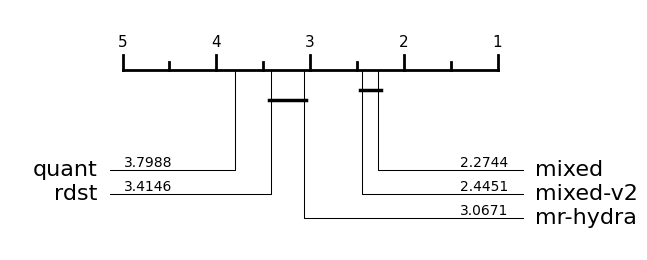

In [6]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [7]:
def dataset_stats():
    import collections
    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append({'dataset': dataset,
                      'n_train': X_train.shape[0],
                      'n_test': X_test.shape[0],
                      'n_classes': len(np.unique(y_train)),
                      'series_length': X_train.shape[2],
                      })
    return pl.DataFrame(stats)

stats = dataset_stats()

In [8]:
joined = v.join(stats, on='dataset').sort('n_train')
joined

dataset,mr-hydra,quant,mixed-v2,rdst,mixed,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.858268,0.868766,0.850394,0.847769,0.858268,17,127,2,288
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.9,0.816667,0.816667,0.95,0.933333,20,20,2,512
"""BirdChicken""",0.9,0.9,0.916667,0.9,0.9,20,20,2,512
"""Chinatown""",0.975705,0.981535,0.980564,0.977648,0.981535,20,343,2,24
…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.846931,0.840326,0.863636,0.806915,0.855866,1800,858,2,80
"""FordA""",0.95303,0.970455,0.999242,0.949242,0.979293,3601,1320,2,500
"""FordB""",0.830453,0.803292,0.848971,0.820988,0.836626,3636,810,2,500


36


(<Figure size 600x240 with 1 Axes>, <Axes: >)

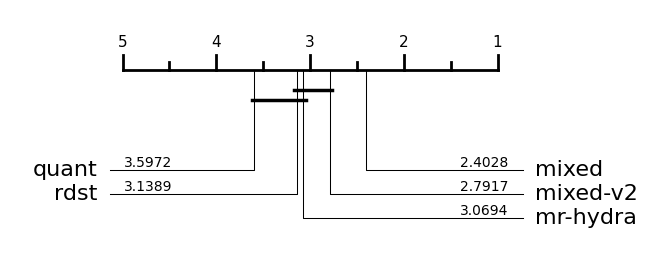

In [9]:
s_small = joined.filter(pl.col('n_train') < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

31


(<Figure size 600x240 with 1 Axes>, <Axes: >)

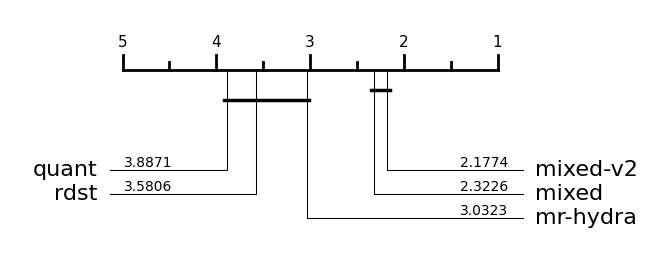

In [10]:
s_medium = joined.filter(pl.col('n_train') >= 200).filter(pl.col('n_train') < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

15


(<Figure size 600x240 with 1 Axes>, <Axes: >)

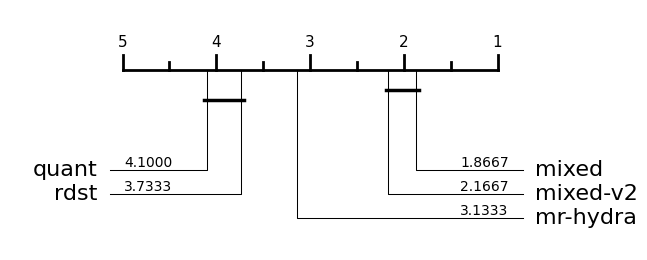

In [11]:
s_large = joined.filter(pl.col('n_train') >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [12]:
s_large

dataset,mr-hydra,quant,mixed-v2,rdst,mixed,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DistalPhalanxOutlineCorrect""",0.801932,0.78744,0.795894,0.777778,0.810386,600,276,2,80
"""ProximalPhalanxOutlineCorrect""",0.919817,0.907216,0.922108,0.886598,0.917526,600,291,2,80
"""ShapesAll""",0.927778,0.871667,0.921667,0.919444,0.928333,600,600,60,512
"""Strawberry""",0.972973,0.968468,0.973874,0.976577,0.976577,613,370,2,235
"""UWaveGestureLibraryAll""",0.979899,0.96743,0.979341,0.980179,0.979806,896,3582,8,945
…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.846931,0.840326,0.863636,0.806915,0.855866,1800,858,2,80
"""FordA""",0.95303,0.970455,0.999242,0.949242,0.979293,3601,1320,2,500
"""FordB""",0.830453,0.803292,0.848971,0.820988,0.836626,3636,810,2,500
